In [141]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_information():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_data = load_information()

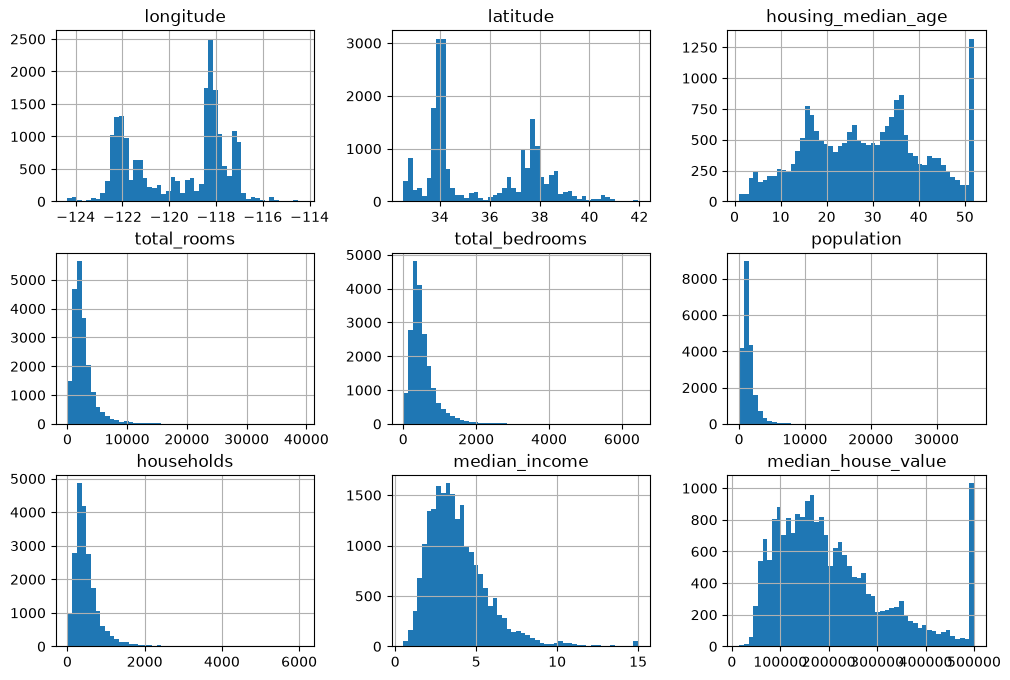

In [142]:
import matplotlib.pyplot as plt

housing_data.hist(bins=50, figsize=(12, 8))
plt.show()

In [143]:
import numpy as np

def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data)*test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [144]:
from zlib import crc32

def is_id_in_testset(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_dataset = ids.apply(lambda id_: is_id_in_testset(id_, test_ratio))
    return data[~in_test_dataset], data[in_test_dataset]

In [145]:
housing_with_id = housing_data.reset_index()
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

In [146]:
housing_with_id["id"] = (housing_with_id["longitude"]*1000 + housing_with_id["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")
print(train_set.head())

   index  longitude  latitude  housing_median_age  total_rooms  \
0      0    -122.23     37.88                41.0        880.0   
1      1    -122.22     37.86                21.0       7099.0   
2      2    -122.24     37.85                52.0       1467.0   
3      3    -122.25     37.85                52.0       1274.0   
4      4    -122.25     37.85                52.0       1627.0   

   total_bedrooms  population  households  median_income  median_house_value  \
0           129.0       322.0       126.0         8.3252            452600.0   
1          1106.0      2401.0      1138.0         8.3014            358500.0   
2           190.0       496.0       177.0         7.2574            352100.0   
3           235.0       558.0       219.0         5.6431            341300.0   
4           280.0       565.0       259.0         3.8462            342200.0   

  ocean_proximity         id  
0        NEAR BAY -122192.12  
1        NEAR BAY -122182.14  
2        NEAR BAY -122202.15 

In [147]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_data, test_size=0.2, random_state=42)

Text(0.5, 0, 'Income category')

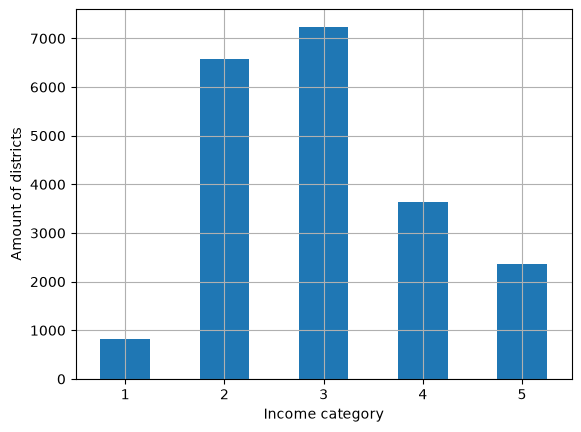

In [148]:
housing_data["income_cat"] = pd.cut(housing_data["median_income"], bins=[0., 1.5, 3., 4.5, 6., np.inf], labels=[1, 2, 3 , 4, 5])

cat_counts = housing_data["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.ylabel("Amount of districts")
plt.xlabel("Income category")

In [149]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

strat_splits = []
for train_indices, test_indices in splitter.split(X=housing_data, y=housing_data["income_cat"]):
    strat_train_set_n = housing_data.iloc[train_indices]
    strat_test_set_n = housing_data.iloc[test_indices]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [150]:
strat_train_set, strat_test_split = strat_splits[0]

In [151]:
strat_train_set, strat_test_set = train_test_split(housing_data, test_size=0.2, stratify=housing_data["income_cat"], random_state=42)

In [152]:
print(strat_test_set["income_cat"].value_counts()/len(strat_test_set))
print(housing_data["income_cat"].value_counts()/len(housing_data))

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64
income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64


In [153]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

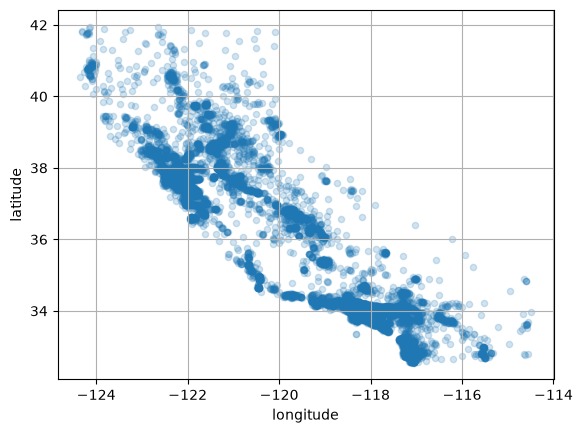

In [154]:
housing = strat_train_set.copy()

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

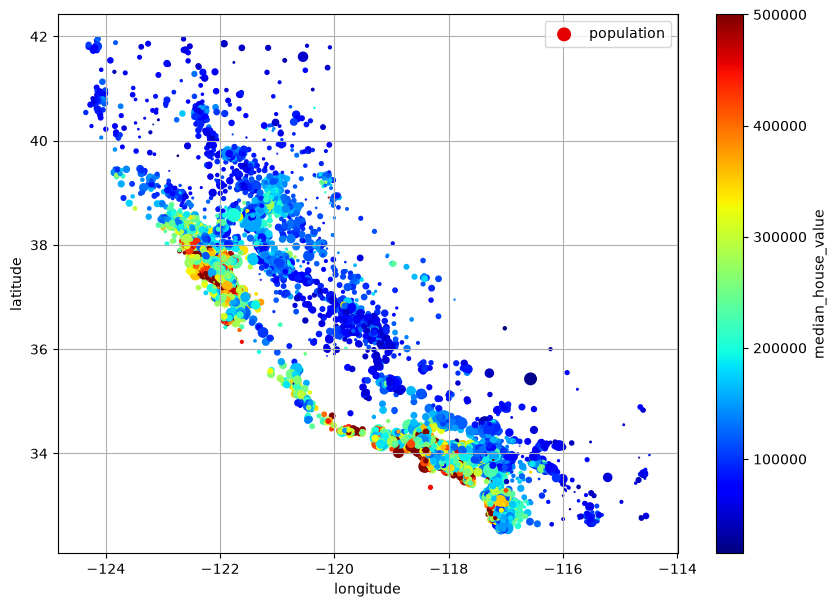

In [155]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, s=housing["population"]/100,
             label="population", c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.show()

In [156]:
corr_matrix = housing.corr(numeric_only=True)

print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64
